# *Sleep Stage Patterns as Non-Invasive Biomarkers for Early Alzheimer's Disease Risk Screening: A Machine Learning Approach*

Class: BA889 Summer 2026

Name: Suji Kim

## 0. Setup

Import all required libraries and mount Google Drive.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
# PART 1: ADNI Analysis

This section processes clinical cognitive assessment data from the Alzheimer's Disease Neuroimaging Initiative (ADNI). The goal is to characterize differences in cognitive scores (MMSE, ADAS-Cog) and demographic variables across diagnostic groups: Cognitively Normal (CN), Mild Cognitive Impairment (MCI), and Alzheimer's Disease (AD).

## 1-1. Data Import

Load all ADNI CSV files from Google Drive.

In [ ]:
path_adni = '/content/drive/MyDrive/BA889/data/adni/'

diag = pd.read_csv(path_adni + 'adni_diagnostic_summary.csv')
mmse = pd.read_csv(path_adni + 'adni_mmse.csv')
adas = pd.read_csv(path_adni + 'adni_adas_cognitive_behavior.csv')
demo = pd.read_csv(path_adni + 'adni_subject_demographics.csv')

print("Diagnostic Summary:", diag.shape)
print("MMSE:",               mmse.shape)
print("ADAS:",               adas.shape)
print("Demographics:",       demo.shape)

Diagnostic Summary: (16149, 41)
MMSE: (14740, 58)
ADAS: (13033, 16)
Demographics: (6149, 84)


The number of rows in each file significantly exceeds the number of participants because the data is longitudinal, capturing records of multiple visits per participant.

- **Diagnostic Summary (16,149 rows / 41 variables)**: A key label file recording diagnostic results (CN, MCI, or AD) for each participant visit.
- **MMSE (14,740 rows / 58 variables)**: Mini-Mental State Examination. Scored out of a maximum of 30 points; lower scores indicate cognitive decline. Generally, a score below 24 suggests possible cognitive impairment.
- **ADAS (13,033 rows / 16 variables)**: Alzheimer's Disease Assessment Scale. Unlike the MMSE, higher scores indicate a state of cognitive decline.
- **Demographics (6,149 rows / 84 variables)**: Contains demographic information such as the participant's age, gender, and education level.

## 1-2. Baseline Extraction (Longitudinal → Cross-Sectional)

ADNI is a longitudinal study. We extract only the baseline visit (`bl` or `sc`) for each participant to create a cross-sectional dataset.

In [ ]:
def get_baseline(df, viscode_col='VISCODE'):
    bl = df[df[viscode_col].isin(['bl', 'sc'])].copy()
    bl = bl.sort_values(viscode_col).groupby('PTID').first().reset_index()
    return bl

diag_bl = get_baseline(diag)
mmse_bl = get_baseline(mmse)
adas_bl = get_baseline(adas)
demo_bl = get_baseline(demo)

print("Baseline rows:")
print(f"  Diagnostic: {len(diag_bl)}")
print(f"  MMSE:       {len(mmse_bl)}")
print(f"  ADAS:       {len(adas_bl)}")
print(f"  Demo:       {len(demo_bl)}")

Baseline rows:
  Diagnostic: 1914
  MMSE:       2257
  ADAS:       1647
  Demo:       2286


We extracted only the first visit (baseline) for each participant from the longitudinal data. This process eliminated data redundancy caused by repeated measurements and converted the data into a format suitable for cross-sectional analysis.

- Diagnostic: Baseline visits extracted for 1,914 participants
- MMSE: 2,257 participants (some participants had MMSE measured only at the screening visit)
- ADAS: 1,647 participants (the count is relatively low because ADAS was measured only at specific visits)
- Demo: 2,286 participants (demographic data is collected only once, resulting in the highest number of rows)

The variation in row counts across files stems from differences in measurement timing and protocols across ADNI phases (ADNI1/GO/2/3/4). Subsequent merging based on PTID ensures that only participants common to the datasets are retained.

## 1-3. Data Merge

Merge all baseline tables on `PTID` to create a single ADNI analysis dataframe.

In [ ]:
diag_bl_clean = diag_bl[['PTID', 'EXAMDATE', 'DIAGNOSIS']].copy()
diag_bl_clean['DIAGNOSIS'] = diag_bl_clean['DIAGNOSIS'].map({1: 'CN', 2: 'MCI', 3: 'AD'})

mmse_bl_clean = mmse_bl[['PTID', 'MMSCORE']].copy()

adas_bl_clean = adas_bl[['PTID', 'TOTSCORE', 'TOTAL13']].rename(
    columns={'TOTSCORE': 'ADAS_TOTAL', 'TOTAL13': 'ADAS_TOTAL13'})

demo_bl_clean = demo_bl[['PTID', 'PTGENDER', 'PTDOBYY', 'PTEDUCAT']].copy()
demo_bl_clean['PTGENDER'] = demo_bl_clean['PTGENDER'].map({1: 'Male', 2: 'Female'})

df_adni = diag_bl_clean.merge(mmse_bl_clean,  on='PTID', how='left').merge(adas_bl_clean, on='PTID', how='left').merge(demo_bl_clean, on='PTID', how='left')

print("Merged shape:", df_adni.shape)
print(df_adni['DIAGNOSIS'].value_counts())
df_adni.head()

Merged shape: (1914, 9)
DIAGNOSIS
MCI    864
CN     744
AD     299
Name: count, dtype: int64


,PTID,EXAMDATE,DIAGNOSIS,MMSCORE,ADAS_TOTAL,ADAS_TOTAL13,PTGENDER,PTDOBYY,PTEDUCAT
0,002_S_0295,2006-05-10,CN,28.0,3.00,4.00,Male,1921-01-01,18.0
1,002_S_0413,2006-05-10,CN,29.0,3.33,4.33,Female,1929-01-01,16.0
2,002_S_0559,2006-06-27,CN,30.0,6.00,8.00,Male,1927-01-01,16.0
3,002_S_0619,2006-06-27,AD,22.0,19.33,30.33,Male,1928-01-01,12.0
4,002_S_0685,2006-07-24,CN,30.0,3.67,6.67,Female,1916-01-01,16.0


Four files were merged using a left join based on the PTID (Participant ID). The final dataset consists of **1,914 individuals and 9 variables**.

Distribution of diagnostic groups:
- **MCI (864 individuals, 45.1%)**: Mild Cognitive Impairment — an intermediate stage between normal cognition and Alzheimer's disease.
- **CN (744 individuals, 38.8%)**: Cognitively Normal — the group with normal cognitive function.
- **AD (299 individuals, 15.6%)**: Alzheimer's Disease — the group diagnosed with Alzheimer's disease.

The relatively low proportion of AD cases is due to the ADNI study design, which includes a large number of participants in the early stages of the condition. Class imbalance will be addressed during subsequent modeling using the `class_weight='balanced'` option.

## 1-4. Preprocessing

Calculate participant age from date of birth, handle outliers and missing values, and impute ADAS scores using group-wise medians.

In [ ]:
df_adni['EXAMDATE'] = pd.to_datetime(df_adni['EXAMDATE'])
df_adni['PTDOBYY']  = pd.to_datetime(df_adni['PTDOBYY'])
df_adni['AGE'] = (df_adni['EXAMDATE'] - df_adni['PTDOBYY']).dt.days / 365.25

# Remove negative education values (data entry errors)
df_adni.loc[df_adni['PTEDUCAT'] < 0, 'PTEDUCAT'] = np.nan

# Drop rows with missing DIAGNOSIS
df_adni = df_adni.dropna(subset=['DIAGNOSIS'])

# Impute ADAS missing values with group median
for col in ['ADAS_TOTAL', 'ADAS_TOTAL13']:
    df_adni[col] = df_adni.groupby('DIAGNOSIS')[col].transform(
        lambda x: x.fillna(x.median()))

df_adni = df_adni.dropna(subset=['MMSCORE', 'PTGENDER', 'AGE', 'PTEDUCAT'])
df_adni = df_adni.drop(columns=['EXAMDATE', 'PTDOBYY'])

print("After preprocessing:", df_adni.shape)
print(df_adni['DIAGNOSIS'].value_counts())
print(df_adni.describe().round(2))

After preprocessing: (1887, 8)
DIAGNOSIS
MCI    857
CN     736
AD     294
Name: count, dtype: int64
       MMSCORE  ADAS_TOTAL  ADAS_TOTAL13  PTEDUCAT      AGE
count  1887.00     1887.00       1887.00   1887.00  1887.00
mean     27.44        9.73         15.38     16.00    73.28
std       2.71        5.97          8.97      2.74     7.60
min       4.00        0.00          0.00      4.00    51.01
25%      26.00        5.33          8.00     14.00    67.90
50%      28.00        8.33         13.67     16.00    73.29
75%      30.00       12.67         20.67     18.00    78.72
max      30.00       42.67         54.67     20.00    91.97


After preprocessing, the final dataset consists of **1,887 individuals and 8 variables**. Twenty-seven individuals were excluded during the preprocessing stage.

Key preprocessing steps:
- **Age (AGE) calculation**: Calculated as the difference between PTDOBYY (date of birth) and EXAMDATE (date of examination) in years.
- **Removal of negative education values**: Values ​​where PTEDUCAT < 0 were treated as data entry errors and marked as missing.
- **ADAS missing value imputation**: Missing values ​​for ADAS_TOTAL/ADAS_TOTAL13 (approximately 15%) were replaced with the median value for each diagnostic group (group-wise median imputation).

Key descriptive statistics:
- Mean MMSCORE: 27.44 (out of 30); reflects the average cognitive function level of the entire cohort.
- Mean ADAS_TOTAL: 9.73; indicates a level of moderate cognitive impairment.
- Mean AGE: 73.28 years; reflects the characteristics of an elderly cohort.
- Mean PTEDUCAT: 16 years; indicates a high level of education (college graduate level), characteristic of ADNI participants.

## 1-5. Missing Value Check

Verify the completeness of the final ADNI dataframe before EDA.

In [ ]:
print("Missing value counts:")
print(df_adni.isnull().sum())
print(f"\nMissing value ratio (%):")
print((df_adni.isnull().sum() / len(df_adni) * 100).round(1))

Missing value counts:
PTID            0
DIAGNOSIS       0
MMSCORE         0
ADAS_TOTAL      0
ADAS_TOTAL13    0
PTGENDER        0
PTEDUCAT        0
AGE             0
dtype: int64

Missing value ratio (%):
PTID            0.0
DIAGNOSIS       0.0
MMSCORE         0.0
ADAS_TOTAL      0.0
ADAS_TOTAL13    0.0
PTGENDER        0.0
PTEDUCAT        0.0
AGE             0.0
dtype: float64


After preprocessing, the number of missing values ​​across all variables was confirmed to be zero.
This indicates that the missing value imputation (using the ADAS group median) and the removal of rows with missing values ​​(dropna) performed in the previous steps were successful.
This complete dataset, free of missing values, is ready for immediate use in subsequent model training without the need for further imputation.

## 1-6. EDA — Cognitive Scores by Diagnosis Group

Visualize MMSE and ADAS-Cog score distributions across CN, MCI, and AD groups. Higher MMSE indicates better cognition; higher ADAS-Cog indicates greater impairment.

/tmp/ipykernel_1591/1930552989.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_adni, x='DIAGNOSIS', y='MMSCORE',
/tmp/ipykernel_1591/1930552989.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_adni, x='DIAGNOSIS', y='ADAS_TOTAL',
/tmp/ipykernel_1591/1930552989.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_adni, x='DIAGNOSIS', y='ADAS_TOTAL13',


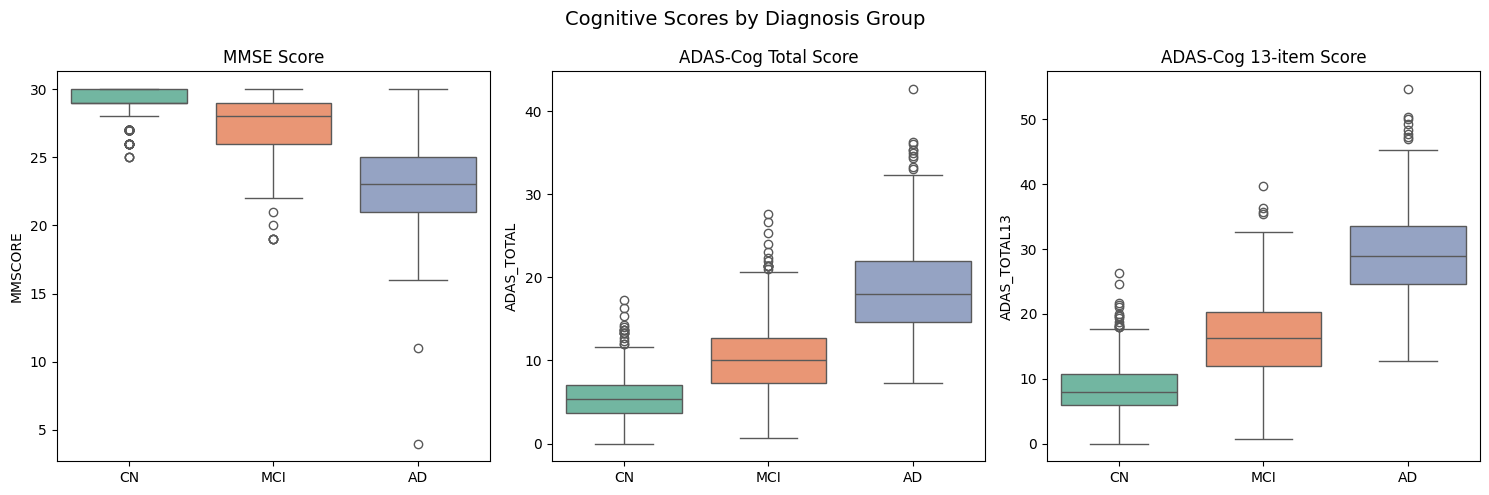

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Cognitive Scores by Diagnosis Group', fontsize=14)

sns.boxplot(data=df_adni, x='DIAGNOSIS', y='MMSCORE',
            order=['CN','MCI','AD'], ax=axes[0], palette='Set2')
axes[0].set_title('MMSE Score'); axes[0].set_xlabel('')

sns.boxplot(data=df_adni, x='DIAGNOSIS', y='ADAS_TOTAL',
            order=['CN','MCI','AD'], ax=axes[1], palette='Set2')
axes[1].set_title('ADAS-Cog Total Score'); axes[1].set_xlabel('')

sns.boxplot(data=df_adni, x='DIAGNOSIS', y='ADAS_TOTAL13',
            order=['CN','MCI','AD'], ax=axes[2], palette='Set2')
axes[2].set_title('ADAS-Cog 13-item Score'); axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig('adni_cognitive_scores.png', dpi=150)
plt.show()

A consistent pattern is observed across all three cognitive function metrics in the progression from CN to MCI to AD.

- MMSE (higher scores indicate normal function): Median values ​​are approximately 29.5 for CN, 28.0 for MCI, and 23.0 for AD, showing a clear downward trend across groups.
Notably, the AD group exhibits a wide distribution (large IQR), indicating significant individual variation in the degree of cognitive decline.
- ADAS_TOTAL / ADAS_TOTAL13 (higher scores indicate cognitive decline): Values ​​increase in the order of CN < MCI < AD;
the presence of numerous outliers in the AD group suggests the inclusion of some severe cases.

There is some overlap in the distributions of the three groups, implying that accurate classification is difficult using a single metric alone
and supporting the need for multivariate machine learning models.

## 1-7. EDA — Gender and Education Level Distribution

Examine demographic differences across diagnostic groups to identify potential confounders.

/tmp/ipykernel_1591/3910737907.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_adni, x='DIAGNOSIS', y='PTEDUCAT',


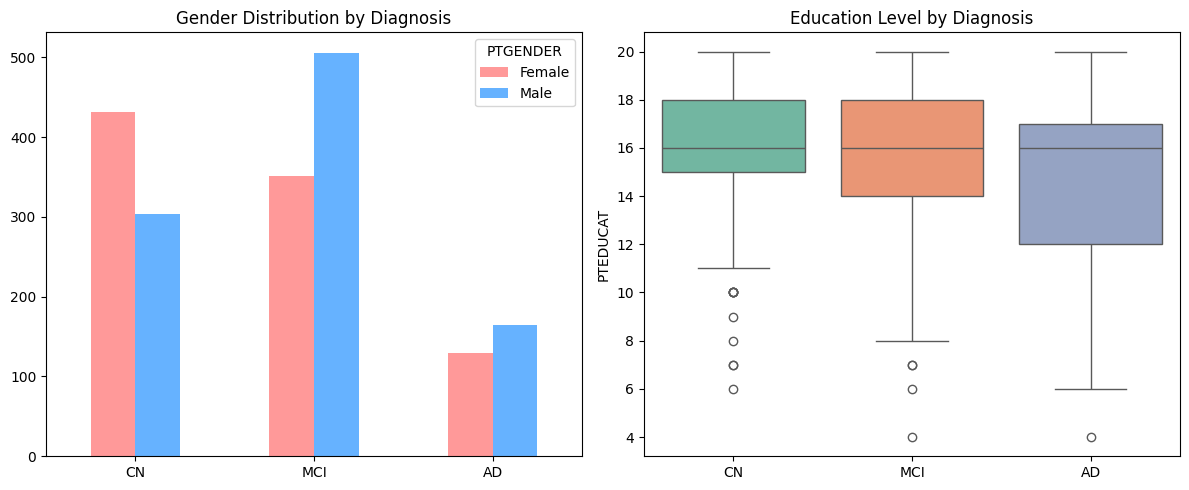

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gender_diag = df_adni.groupby(['DIAGNOSIS', 'PTGENDER']).size().unstack()
gender_diag.loc[['CN','MCI','AD']].plot(kind='bar', ax=axes[0],
                                         color=['#FF9999','#66B2FF'])
axes[0].set_title('Gender Distribution by Diagnosis')
axes[0].set_xlabel(''); axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(data=df_adni, x='DIAGNOSIS', y='PTEDUCAT',
            order=['CN','MCI','AD'], ax=axes[1], palette='Set2')
axes[1].set_title('Education Level by Diagnosis')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('adni_demographics.png', dpi=150)
plt.show()

Regarding gender distribution, the MCI group contains significantly more men (506) than women (351),
whereas the CN group has more women (439) than men (301).
This reflects the gender-based differences in MCI incidence rates known from previous studies.

The median level of education is similar across the three groups (approximately 16 years, equivalent to a college degree),
suggesting that education level is not a major factor in distinguishing between the diagnostic groups.
Note that some outliers (negative values) were already removed during the preprocessing stage.
As education level is a variable associated with cognitive reserve, it is appropriate to include it in the model
but interpret it as a secondary variable rather than a primary one.

## 1-8. EDA — Age Distribution

Compare age distributions across diagnostic groups. Age is a major risk factor for Alzheimer's disease.

/tmp/ipykernel_1591/1165535789.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_adni, x='DIAGNOSIS', y='AGE',


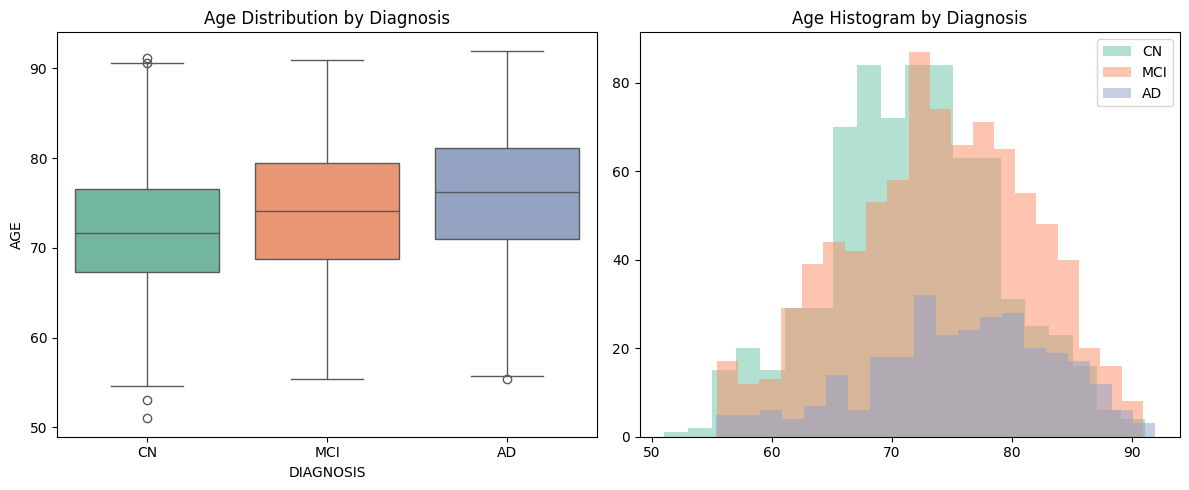

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_adni, x='DIAGNOSIS', y='AGE',
            order=['CN','MCI','AD'], ax=axes[0], palette='Set2')
axes[0].set_title('Age Distribution by Diagnosis')

for grp, color in zip(['CN','MCI','AD'], ['#66c2a5','#fc8d62','#8da0cb']):
    axes[1].hist(df_adni[df_adni['DIAGNOSIS'] == grp]['AGE'],
                 alpha=0.5, label=grp, color=color, bins=20)
axes[1].set_title('Age Histogram by Diagnosis')
axes[1].legend()

plt.tight_layout()
plt.savefig('adni_age_distribution.png', dpi=150)
plt.show()

Regarding age distribution, the median age of the AD group (approximately 76 years) is higher than that of the CN group (approximately 72 years),
which aligns with existing research findings indicating a positive correlation between age and the risk of Alzheimer's disease.

However, the age distributions of the three groups overlap significantly in the histogram,
making it difficult to clearly distinguish between them based on age alone.
This implies that while age is a risk factor, it has limitations as a standalone predictor,
suggesting that combining it with cognitive function variables—such as MMSE and ADAS—is essential for improving classification performance.

## 1-9. EDA — Feature Correlation Heatmap

Examine correlations among numeric features. Note: ADAS_TOTAL and ADAS_TOTAL13 show very high multicollinearity (r ≈ 0.97), which will be addressed in the modeling stage.

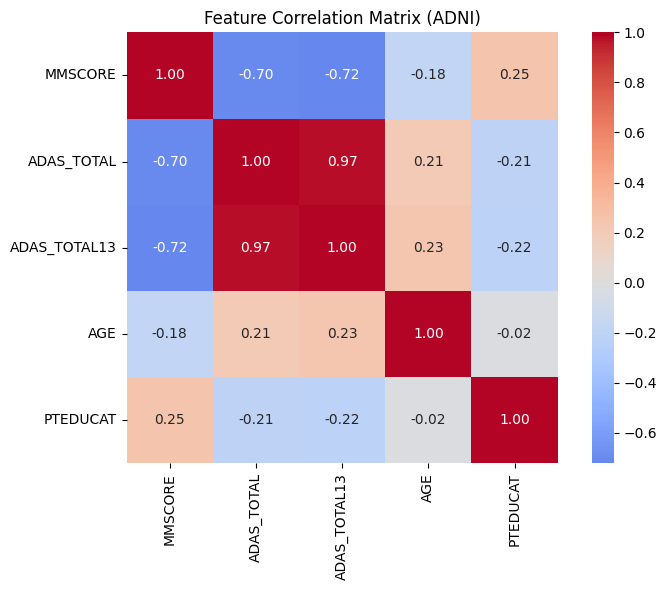

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

corr_cols = ['MMSCORE', 'ADAS_TOTAL', 'ADAS_TOTAL13', 'AGE', 'PTEDUCAT']
sns.heatmap(df_adni[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Feature Correlation Matrix (ADNI)')
plt.tight_layout()
plt.savefig('adni_correlation_heatmap.png', dpi=150)
plt.show()

Key correlation results:

1. MMSCORE ↔ ADAS_TOTAL (-0.70), ADAS_TOTAL13 (-0.72):
A strong negative correlation confirms that the two metrics measure cognitive function in opposite directions.
This result is theoretically consistent, as higher MMSE scores indicate normal function, whereas higher ADAS scores indicate greater impairment.

2. ADAS_TOTAL ↔ ADAS_TOTAL13 (0.97):
A very high positive correlation indicates the presence of multicollinearity.
Including both variables in the model could lead to coefficient instability;
therefore, only ADAS_TOTAL will be used in subsequent modeling, and ADAS_TOTAL13 will be excluded.

3. AGE ↔ Cognitive function variables (absolute values ​​of 0.18–0.23):
A weak correlation indicates that age alone does not sufficiently explain cognitive function.

4. PTEDUCAT ↔ MMSCORE (0.25):
Higher levels of education tend to be associated with slightly higher MMSE scores,
indirectly supporting the cognitive reserve hypothesis.

---
# PART 2: SHHS (NSRR) Analysis

This section processes polysomnography (PSG) sleep data from the Sleep Heart Health Study (SHHS), accessed via the National Sleep Research Resource (NSRR). The harmonized dataset provides standardized sleep architecture variables for 5,804 adults aged 40–89.

## 2-1. Data Import

Load the SHHS harmonized dataset and filter to baseline visits (visitnumber == 1).

In [ ]:
path_nsrr = '/content/drive/MyDrive/BA889/data/nsrr/'

shhs_raw = pd.read_csv(path_nsrr + 'shhs-harmonized-dataset-0.21.0.csv')
shhs1    = shhs_raw[shhs_raw['visitnumber'] == 1].copy()

print("SHHS harmonized (all visits):", shhs_raw.shape)
print("SHHS1 (baseline only):",        shhs1.shape)
print("\nColumns:", list(shhs1.columns))

SHHS harmonized (all visits): (10115, 29)
SHHS1 (baseline only): (5804, 29)

Columns: ['nsrrid', 'visitnumber', 'nsrr_age', 'nsrr_age_gt89', 'nsrr_sex', 'nsrr_race', 'nsrr_ethnicity', 'nsrr_bmi', 'nsrr_bp_systolic', 'nsrr_bp_diastolic', 'nsrr_current_smoker', 'nsrr_ever_smoker', 'nsrr_ahi_hp3u', 'nsrr_ahi_hp3r_aasm15', 'nsrr_ahi_hp4u_aasm15', 'nsrr_ahi_hp4r', 'nsrr_ttldursp_f1', 'nsrr_phrnumar_f1', 'nsrr_flag_spsw', 'nsrr_ttleffsp_f1', 'nsrr_ttllatsp_f1', 'nsrr_ttlprdsp_s1sr', 'nsrr_ttldursp_s1sr', 'nsrr_ttldurws_f1', 'nsrr_pctdursp_s1', 'nsrr_pctdursp_s2', 'nsrr_pctdursp_s3', 'nsrr_pctdursp_sr', 'nsrr_ttlprdbd_f1']


The SHHS harmonized dataset consists of a total of 10,115 rows, encompassing data from both SHHS1 (initial visit) and SHHS2 (follow-up visit).
Data for 5,804 participants from the baseline visit were extracted by filtering for `visitnumber == 1`.
The harmonized dataset—a version in which NSRR has standardized variable names and units across multiple sleep studies—is better suited for direct analysis than the raw data.

## 2-2. Sleep Feature Selection

Select key sleep architecture variables relevant to cognitive health research: sleep stage percentages, sleep efficiency, sleep latency, wake after sleep onset (WASO), apnea-hypopnea index (AHI), and arousal index.

In [ ]:
sleep_cols = [
    'nsrrid',
    'nsrr_age',
    'nsrr_sex',
    'nsrr_bmi',
    'nsrr_pctdursp_s1',    # Stage 1 %
    'nsrr_pctdursp_s2',    # Stage 2 %
    'nsrr_pctdursp_s3',    # Stage 3 (Deep / Slow-Wave Sleep) %
    'nsrr_pctdursp_sr',    # REM %
    'nsrr_ttleffsp_f1',    # Sleep Efficiency
    'nsrr_ttllatsp_f1',    # Sleep Latency (minutes)
    'nsrr_ttldurws_f1',    # WASO (minutes)
    'nsrr_ahi_hp3u',       # AHI (Apnea-Hypopnea Index)
    'nsrr_phrnumar_f1',    # Arousal Index (events/hour)
]

df_shhs = shhs1[sleep_cols].copy()
print("Selected features shape:", df_shhs.shape)
df_shhs.head()

Selected features shape: (5804, 13)


,nsrrid,nsrr_age,nsrr_sex,nsrr_bmi,nsrr_pctdursp_s1,nsrr_pctdursp_s2,nsrr_pctdursp_s3,nsrr_pctdursp_sr,nsrr_ttleffsp_f1,nsrr_ttllatsp_f1,nsrr_ttldurws_f1,nsrr_ahi_hp3u,nsrr_phrnumar_f1
0,200001,55.0,male,21.777553,6.26,60.85,19.31,13.58,85.24,0.0,65.0,4.31,25.25
1,200002,78.0,male,32.950680,0.82,65.66,16.76,16.76,80.89,0.0,43.0,31.32,26.70
2,200003,77.0,female,24.114150,4.88,40.31,42.82,11.99,83.08,0.0,73.0,8.87,23.10
3,200004,48.0,male,20.185185,2.99,29.40,52.33,15.28,83.96,14.0,43.5,2.99,5.98
4,200005,66.0,female,23.309053,5.68,68.65,13.38,12.30,77.57,6.5,100.5,6.16,17.03


Thirteen sleep-related variables were selected. The meaning of each variable is as follows.

| Variable Name | Description |
|---|---|
| nsrr_age | Participant age |
| nsrr_sex | Sex (male / female) |
| nsrr_bmi | Body Mass Index (BMI) |
| nsrr_pctdursp_s1 | Percentage of total sleep time in Stage 1 (%) — light sleep |
| nsrr_pctdursp_s2 | Percentage of total sleep time in Stage 2 (%) — intermediate sleep |
| nsrr_pctdursp_s3 | Percentage of total sleep time in Stage 3 (%) — deep sleep (Slow-Wave Sleep) |
| nsrr_pctdursp_sr | Percentage of total sleep time in REM (%) — dream sleep; associated with memory consolidation |
| nsrr_ttleffsp_f1 | Sleep Efficiency — ratio of actual sleep time to time spent in bed |
| nsrr_ttllatsp_f1 | Sleep Latency — time taken to fall asleep (minutes) |
| nsrr_ttldurws_f1 | WASO (Wake After Sleep Onset) — duration of wakefulness after falling asleep (minutes) |
| nsrr_ahi_hp3u | AHI (Apnea-Hypopnea Index) — number of apnea/hypopnea events per hour; indicator of sleep apnea severity |
| nsrr_phrnumar_f1 | Arousal Index — number of arousals during sleep per hour |

In particular, the proportions of Stage 3 (deep sleep) and REM sleep are key variables directly linked to amyloid plaque clearance and memory consolidation in Alzheimer's research, making them primary features of interest in this study.

## 2-3. Preprocessing

Filter participants to ages 40–89 (aligned with ADNI age range) and remove rows with missing values.

In [ ]:
# Filter age range consistent with ADNI population
df_shhs = df_shhs[
    (df_shhs['nsrr_age'] >= 40) &
    (df_shhs['nsrr_age'] <= 89)
].copy()

# Drop missing values
df_shhs = df_shhs.dropna()

print("After preprocessing:", df_shhs.shape)
print("\nDescriptive Statistics:")
print(df_shhs.describe().round(2))

After preprocessing: (5576, 13)

Descriptive Statistics:
          nsrrid  nsrr_age  nsrr_bmi  nsrr_pctdursp_s1  nsrr_pctdursp_s2  \
count    5576.00   5576.00   5576.00           5576.00           5576.00   
mean   202924.88     63.01     28.17              5.43             56.51   
std      1681.47     11.03      5.07              3.94             11.71   
min    200001.00     40.00     18.00              0.00             10.88   
25%    201466.75     55.00     24.69              2.76             48.94   
50%    202960.50     63.00     27.51              4.54             56.79   
75%    204382.25     72.00     30.76              7.04             64.48   
max    205804.00     89.00     50.00             39.12            100.00   

       nsrr_pctdursp_s3  nsrr_pctdursp_sr  nsrr_ttleffsp_f1  nsrr_ttllatsp_f1  \
count           5576.00           5576.00           5576.00           5576.00   
mean              18.23             19.84             82.88             14.06   
std            

After restricting the age range to 40–89 years and removing cases with missing data, a final sample of 5,576 individuals was included in the analysis (a reduction of 228 individuals, or 3.9%, from the original 5,804). The age range was aligned with that of the ADNI cohort (51–89 years) to ensure demographic homogeneity when comparing and discussing the results from both datasets.

Interpretation of key descriptive statistics:
- Mean age 63.01 years (SD 11.03): Approximately 10 years younger than the ADNI mean of 73.28 years,
indicating that the SHHS cohort encompasses a broader age range.
- Mean BMI 28.17: Falls within the overweight range (25–30); this is a notable variable given
the association of obesity with sleep apnea and reduced sleep quality.
- Mean Stage 1 percentage 5.43: Slightly higher than the standard for healthy adults (2–5%),
suggesting the presence of some sleep fragmentation.
- Mean Stage 2 percentage 56.51: Within the normal range (45–60%).
- Mean Stage 3 percentage 18.2: Within the normal range (15–25%), indicating adequate slow-wave sleep.
- Mean REM percentage 19.8: Slightly lower than the standard (20–25%); considering the proportion
of older participants, this likely reflects age-related reductions in REM sleep.
- Mean sleep efficiency 82.9: Below the clinical standard (≥85%), suggesting overall reduced sleep quality. - Average AHI of 14.6: This falls on the borderline of mild sleep apnea (5–15)
and indicates that sleep apnea is highly prevalent within the cohort.

## 2-4. Missing Value Check

Verify completeness of the SHHS dataframe after preprocessing.

In [ ]:
print("Missing value counts:")
print(df_shhs.isnull().sum())

Missing value counts:
nsrrid              0
nsrr_age            0
nsrr_sex            0
nsrr_bmi            0
nsrr_pctdursp_s1    0
nsrr_pctdursp_s2    0
nsrr_pctdursp_s3    0
nsrr_pctdursp_sr    0
nsrr_ttleffsp_f1    0
nsrr_ttllatsp_f1    0
nsrr_ttldurws_f1    0
nsrr_ahi_hp3u       0
nsrr_phrnumar_f1    0
dtype: int64


Following preprocessing, the count of missing values ​​across all 13 variables was confirmed to be zero.
The SHHS harmonized dataset has already undergone standardization and quality verification by the NSRR,
resulting in significantly fewer missing values ​​compared to the original PSG files.
With a complete dataset free of missing values ​​secured, subsequent visualization and correlation analyses
can be performed immediately without the need for additional imputation.

## 2-5. EDA — Sleep Variable Distributions

Visualize the distribution of each sleep architecture variable across the SHHS cohort.

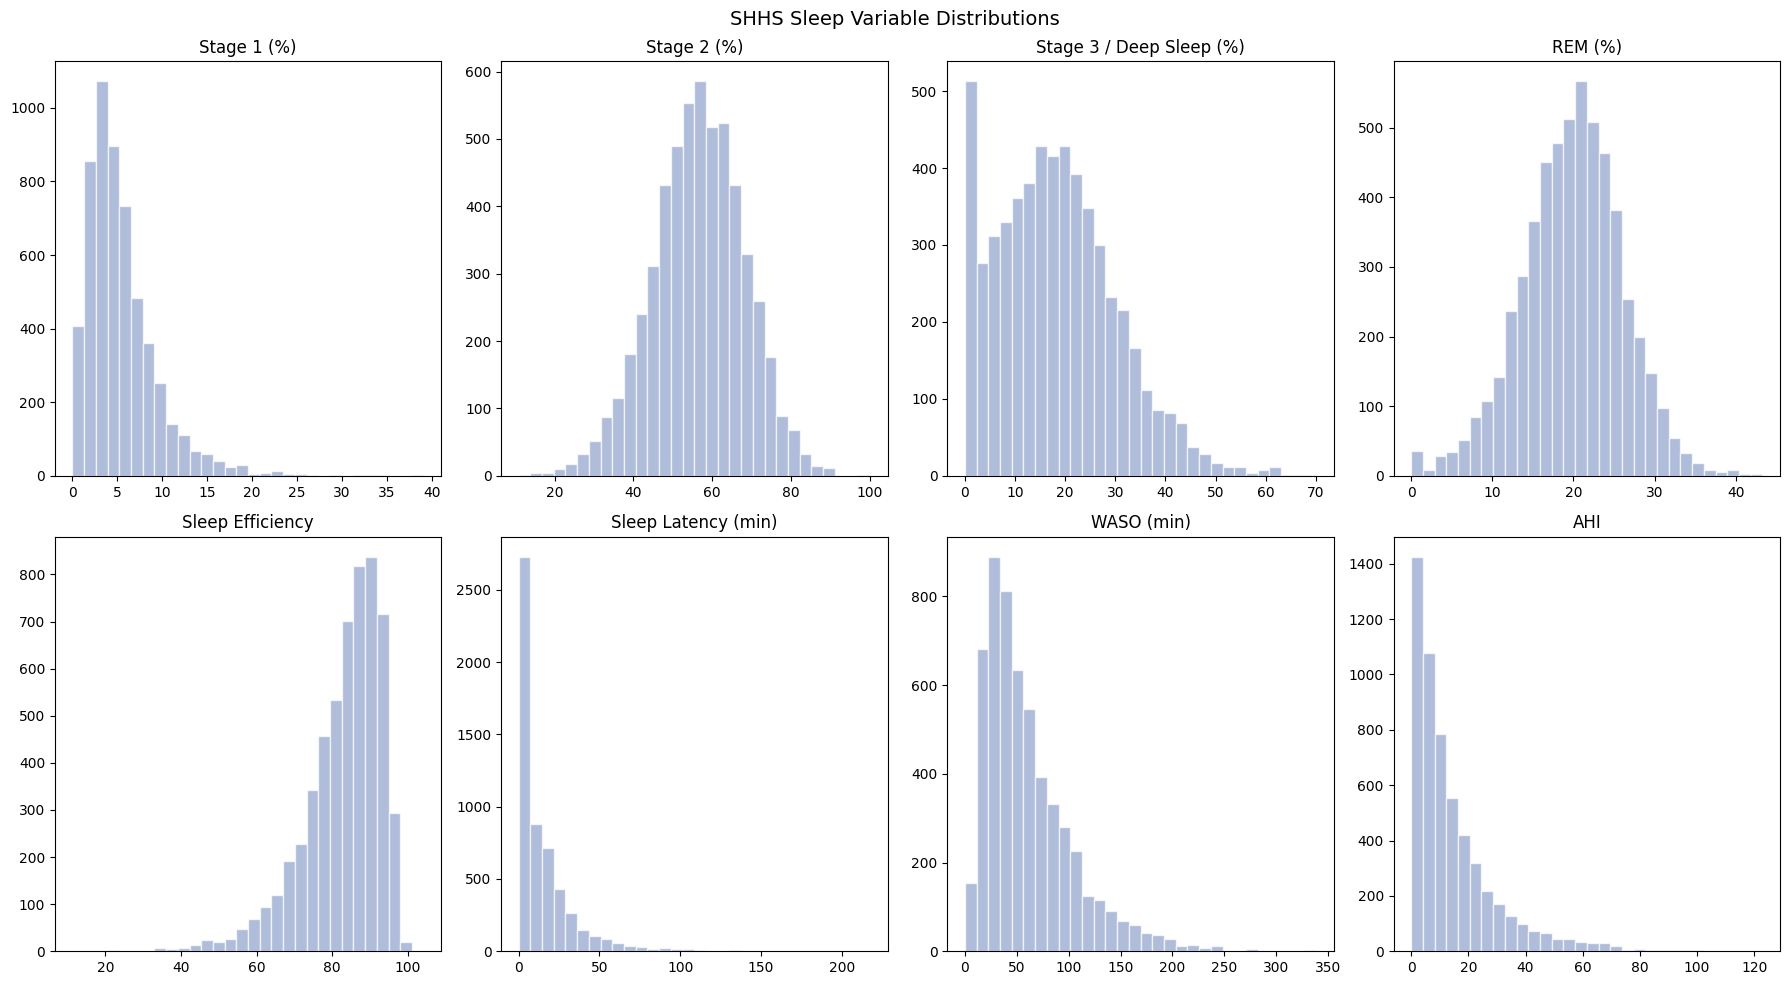

In [ ]:
plot_vars = [
    ('nsrr_pctdursp_s1',  'Stage 1 (%)'),
    ('nsrr_pctdursp_s2',  'Stage 2 (%)'),
    ('nsrr_pctdursp_s3',  'Stage 3 / Deep Sleep (%)'),
    ('nsrr_pctdursp_sr',  'REM (%)'),
    ('nsrr_ttleffsp_f1',  'Sleep Efficiency'),
    ('nsrr_ttllatsp_f1',  'Sleep Latency (min)'),
    ('nsrr_ttldurws_f1',  'WASO (min)'),
    ('nsrr_ahi_hp3u',     'AHI'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('SHHS Sleep Variable Distributions', fontsize=14)

for ax, (col, title) in zip(axes.flatten(), plot_vars):
    ax.hist(df_shhs[col], bins=30, color='#8da0cb', alpha=0.7, edgecolor='white')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('shhs_sleep_distributions.png', dpi=150)
plt.show()

The following characteristics are observed in the distributions of the eight sleep variables:

- Stage 1 (%): A right-skewed distribution concentrated between 0% and 10%.
Most participants show a low percentage of Stage 1 sleep, though high percentages are observed in some cases.
- Stage 2 (%): A relatively normal distribution concentrated in the 40–70% range.
Stage 2 accounts for the largest proportion of adult sleep.
- Stage 3 / Deep Sleep (%): A wide distribution spanning the 0–40% range.
There is significant inter-individual variation; differences are pronounced, with some participants showing almost no deep sleep while others reach up to 40%.
- REM (%): A relatively normal distribution in the 10–35% range.
REM percentage is directly linked to memory consolidation and cognitive function, making it one of the most important features in this study.
- Sleep Efficiency: A left-skewed distribution within the 60–100% range.
Most participants exhibit sleep efficiency above 70%, though a small number show low efficiency.
- Sleep Latency: A strongly right-skewed distribution.
While most participants fall asleep within 30 minutes, there are cases taking over 60 minutes, suggesting potential sleep disorders.
- WASO: A right-skewed distribution; most participants experience brief periods of wakefulness during the night, but significant wakefulness is observed in some.
- AHI: A strongly right-skewed distribution. Although many fall within the normal range (0 to <5),
a significant number of cases show severe sleep apnea (AHI ≥ 30).
The mean AHI of 14.6 corresponds to mild sleep apnea.

## 2-6. EDA — Sleep Architecture by Age Group and Sex

Examine how sleep stage proportions vary by age group and sex — key covariates when interpreting cognitive risk.

/tmp/ipykernel_1591/1708925864.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_shhs, x='age_group', y=col,
/tmp/ipykernel_1591/1708925864.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_shhs, x='age_group', y=col,
/tmp/ipykernel_1591/1708925864.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_shhs, x='age_group', y=col,
/tmp/ipykernel_1591/1708925864.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `le

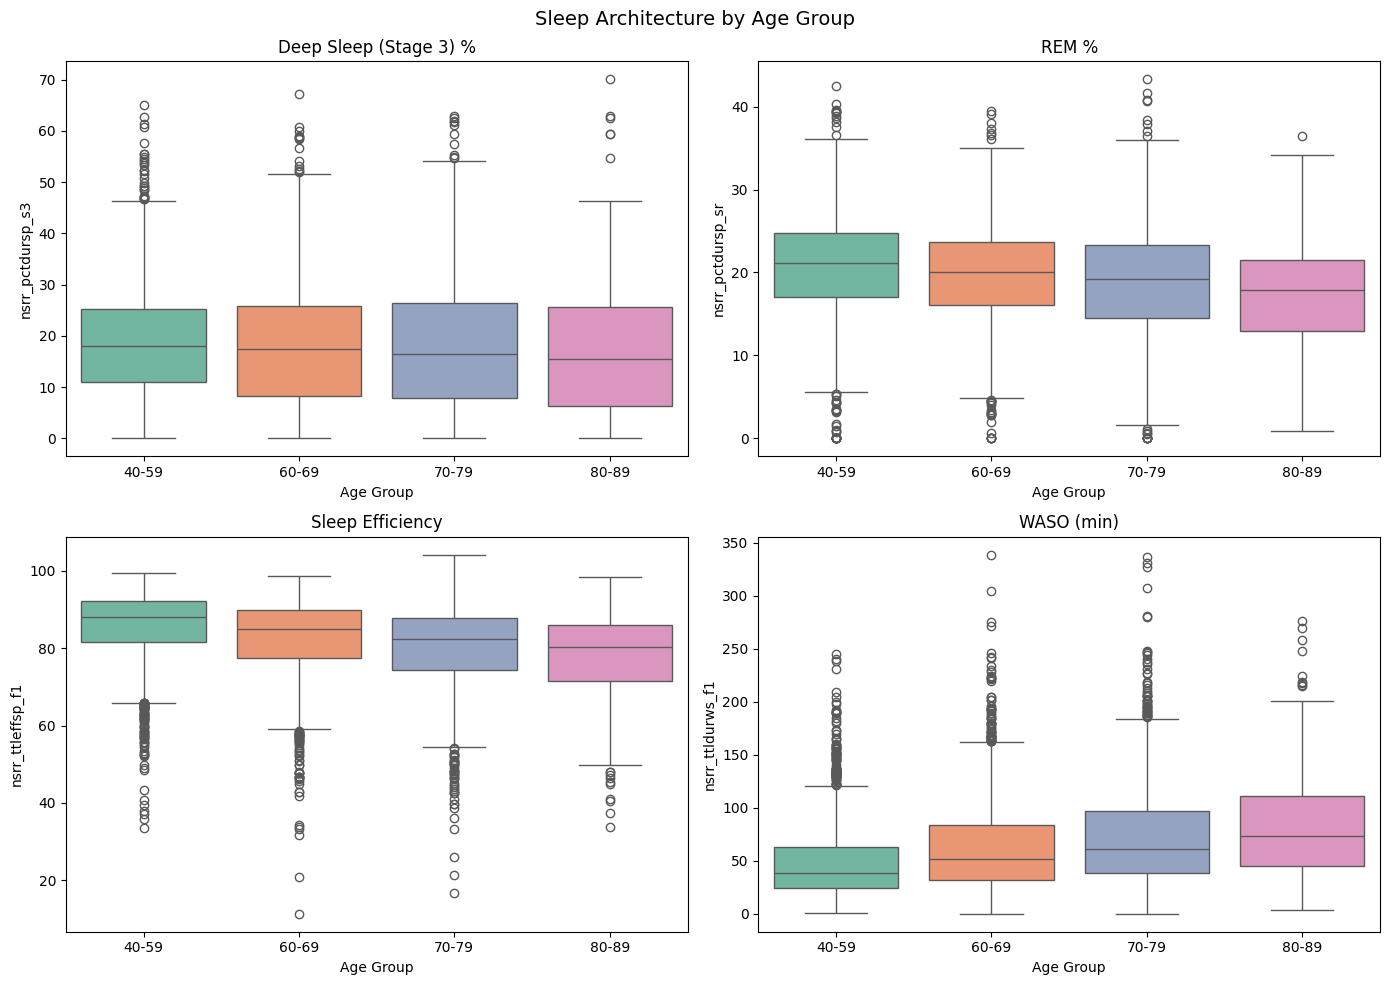

In [ ]:
# Create age groups matching ADNI range
df_shhs['age_group'] = pd.cut(df_shhs['nsrr_age'],
                               bins=[40, 59, 69, 79, 89],
                               labels=['40-59','60-69','70-79','80-89'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sleep Architecture by Age Group', fontsize=14)

for ax, (col, title) in zip(axes.flatten(), [
    ('nsrr_pctdursp_s3', 'Deep Sleep (Stage 3) %'),
    ('nsrr_pctdursp_sr', 'REM %'),
    ('nsrr_ttleffsp_f1', 'Sleep Efficiency'),
    ('nsrr_ttldurws_f1', 'WASO (min)'),
]):
    sns.boxplot(data=df_shhs, x='age_group', y=col,
                ax=ax, palette='Set2')
    ax.set_title(title)
    ax.set_xlabel('Age Group')

plt.tight_layout()
plt.savefig('shhs_sleep_by_age.png', dpi=150)
plt.show()

An examination of changes in sleep architecture across age groups (40–59, 60–69, 70–79, and 80–89 years old) reveals the following:

- Deep Sleep (Stage 3) %: A clear downward trend is observed, with the median value decreasing as age increases. The difference between the 40s and 80s age groups is substantial, aligning with the well-known phenomenon of age-related decline in slow-wave sleep. In Alzheimer's research, this reduction in slow-wave sleep is gaining attention due to its association with a diminished capacity for the brain to clear amyloid plaques.
- REM %: A slight downward trend is observed with increasing age; notably, the distribution widens in the 80s age group, indicating greater inter-individual variability. Previous studies have linked reduced REM sleep to cognitive decline and an increased risk of Alzheimer's disease.
- Sleep Efficiency: A tendency toward lower sleep efficiency is observed in older age groups, reflecting age-related increases in sleep fragmentation.
- WASO: A pattern of increasing wake time after sleep onset (WASO) emerges with advancing age, suggesting reduced sleep continuity among older adults.

These age-related sleep patterns—combined with the established link between age and cognitive decline observed in the ADNI study—indirectly support the potential for sleep changes to serve as biomarkers for Alzheimer's disease risk.

## 2-7. EDA — Sleep Feature Correlation Heatmap

Examine correlations among sleep variables to identify multicollinearity before modeling.

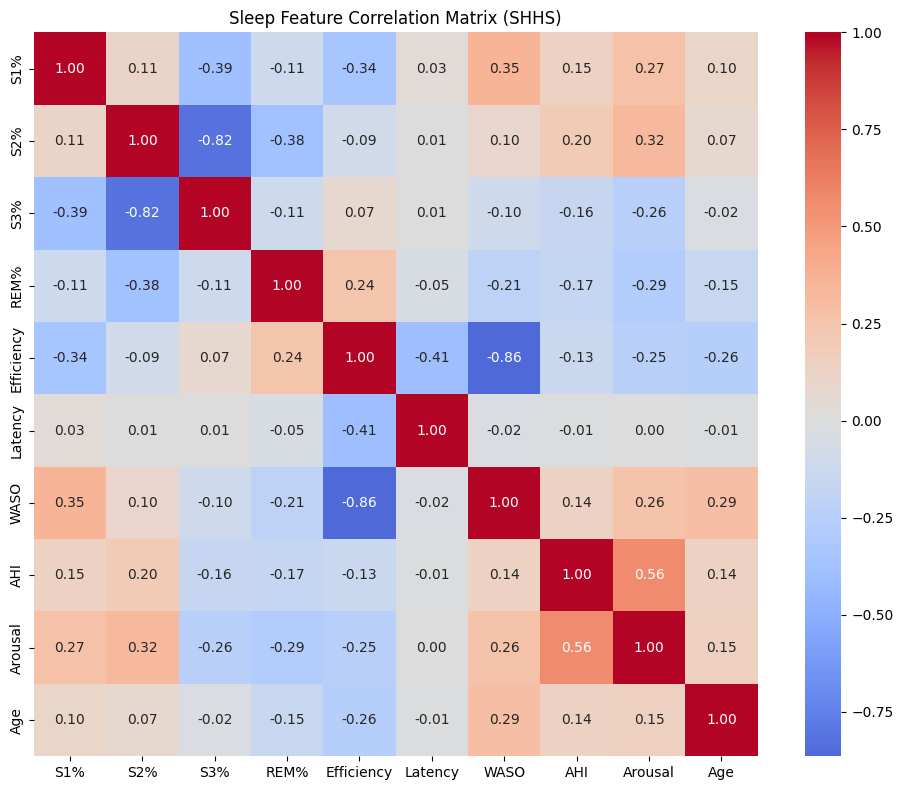

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

sleep_feature_cols = [
    'nsrr_pctdursp_s1', 'nsrr_pctdursp_s2',
    'nsrr_pctdursp_s3', 'nsrr_pctdursp_sr',
    'nsrr_ttleffsp_f1', 'nsrr_ttllatsp_f1',
    'nsrr_ttldurws_f1', 'nsrr_ahi_hp3u',
    'nsrr_phrnumar_f1', 'nsrr_age'
]

sns.heatmap(df_shhs[sleep_feature_cols].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax,
            xticklabels=['S1%','S2%','S3%','REM%','Efficiency',
                         'Latency','WASO','AHI','Arousal','Age'],
            yticklabels=['S1%','S2%','S3%','REM%','Efficiency',
                         'Latency','WASO','AHI','Arousal','Age'])
ax.set_title('Sleep Feature Correlation Matrix (SHHS)')
plt.tight_layout()
plt.savefig('shhs_correlation_heatmap.png', dpi=150)
plt.show()

Key correlations among sleep variables:

1. Stage 1 % ↔ Sleep Efficiency (Negative correlation):
A higher proportion of Stage 1 (light sleep) tends to be associated with lower sleep efficiency,
reflecting the relationship between sleep fragmentation and reduced sleep quality.

2. Stage 2 % ↔ Stage 3 % (Negative correlation):
Stage 2 and Stage 3 share a complementary relationship; an increase in one corresponds to a decrease in the other.
This is a structural correlation resulting from the fact that the sum of sleep stage proportions is constant.

3. AHI ↔ Arousal Index (Strong positive correlation):
Greater severity of sleep apnea is associated with more frequent arousals during sleep;
this is a physiologically consistent finding.

4. WASO ↔ Sleep Efficiency (Strong negative correlation):
This reflects the intuitive relationship where longer periods of wakefulness after sleep onset (WASO)
lead to lower sleep efficiency.

5. Age ↔ Stage 3 % (Negative correlation):
The previously observed pattern—where the proportion of deep sleep decreases with age—
is confirmed here through correlation analysis.

During the modeling phase, it is necessary to carefully examine the impact of multicollinearity
between variable pairs that exhibit high correlations (e.g., AHI–Arousal, WASO–Efficiency).

---
# PART 3: Modeling

Using the preprocessed ADNI dataset (which contains diagnostic labels CN/MCI/AD), we train and evaluate three classification models: Logistic Regression, Random Forest, and XGBoost. ADAS_TOTAL13 is excluded due to high multicollinearity with ADAS_TOTAL (r = 0.97).

## 3-1. Feature Preparation & Train/Test Split

Select final features, encode categorical variables, and split data into training (80%) and test (20%) sets using stratified sampling.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Use ADAS_TOTAL only (drop ADAS_TOTAL13 due to multicollinearity)
X = df_adni[['MMSCORE', 'ADAS_TOTAL', 'AGE', 'PTEDUCAT', 'PTGENDER']].copy()
y = df_adni['DIAGNOSIS'].copy()

X['PTGENDER'] = X['PTGENDER'].map({'Male': 1, 'Female': 0})

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Class order:", le.classes_)  # CN=0, MCI=1, AD=2

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("Class distribution (train):", pd.Series(y_train).value_counts().to_dict())

Class order: ['AD' 'CN' 'MCI']
Train: (1509, 5) | Test: (378, 5)
Class distribution (train): {2: 685, 1: 589, 0: 235}


The five features selected for the final model are MMSCORE, ADAS_TOTAL, AGE, PTEDUCAT, and PTGENDER.
During correlation analysis, ADAS_TOTAL13 was excluded due to high multicollinearity with ADAS_TOTAL (r=0.97).

The data was split into training and testing sets at an 80:20 ratio,
and the `stratify` option was applied to ensure the proportions of CN, MCI, and AD remained consistent across both sets.

Class distribution of the training set:
- MCI: 685 (45.4%)
- CN: 589 (39.0%)
- AD: 235 (15.6%)

As there is class imbalance—specifically, a relatively small AD group—
the `class_weight='balanced'` option will be applied during subsequent model training to address this.

## 3-2. Model Training

Train Logistic Regression, Random Forest, and XGBoost classifiers. `class_weight='balanced'` is applied to account for class imbalance (CN: 736, MCI: 857, AD: 294).

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import xgboost as xgb

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100, random_state=42,
        eval_metric='mlogloss', verbosity=0),
}

results = {}
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)
    auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
    results[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob, 'auc': auc}

    print(f"\n{'='*45}")
    print(f"[{name}]  AUC-ROC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


[Logistic Regression]  AUC-ROC: 0.8814
              precision    recall  f1-score   support

          AD       0.71      0.80      0.75        59
          CN       0.74      0.87      0.80       147
         MCI       0.78      0.62      0.69       172

    accuracy                           0.75       378
   macro avg       0.74      0.76      0.75       378
weighted avg       0.75      0.75      0.74       378


[Random Forest]  AUC-ROC: 0.8880
              precision    recall  f1-score   support

          AD       0.85      0.68      0.75        59
          CN       0.73      0.78      0.75       147
         MCI       0.71      0.71      0.71       172

    accuracy                           0.73       378
   macro avg       0.76      0.72      0.74       378
weighted avg       0.74      0.73      0.73       378


[XGBoost]  AUC-ROC: 0.8847
              precision    recall  f1-score   support

          AD       0.80      0.68      0.73        59
          CN       0.73    

Initial training results for the three models:

| Model | AUC-ROC | Accuracy |
|---|---|---|
| Logistic Regression | 0.881 | 0.75 |
| Random Forest | 0.888 | 0.73 |
| XGBoost | 0.885 | 0.73 |

**AUC-ROC Interpretation**: A score of 0.8 or higher is considered clinically useful, while 0.9 or higher is considered excellent. All three models achieved scores above 0.88, demonstrating good performance.

**Performance by Class (based on Logistic Regression)**:
- AD (recall 0.80): Accurately detected 80% of actual AD patients. As this is the most critical metric for a screening model, the model shows excellent capability in not missing AD cases.
- CN (recall 0.87): Showed the highest detection rate among the groups.
- MCI (recall 0.62): Showed the lowest detection rate among the three groups. MCI shares characteristics intermediate between CN and AD, making it difficult to distinguish; this is a limitation common to all the models.

The AUC-ROC (0.88) is higher than the Accuracy (0.75) because AUC-ROC is a metric that is more robust to class imbalance.

## 3-3. Hyperparameter Tuning (Random Forest & XGBoost)

Apply GridSearchCV to the two best-performing tree-based models to optimize hyperparameters.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5],
}
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_param_grid, cv=5, scoring='roc_auc_ovr_weighted', n_jobs=-1)
rf_grid.fit(X_train_sc, y_train)
print("Best RF params:", rf_grid.best_params_)

# XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [3, 6],
    'learning_rate':[0.05, 0.1],
}
xgb_grid = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0),
    xgb_param_grid, cv=5, scoring='roc_auc_ovr_weighted', n_jobs=-1)
xgb_grid.fit(X_train_sc, y_train)
print("Best XGB params:", xgb_grid.best_params_)

# Re-evaluate tuned models
for name, grid in [('Random Forest (Tuned)', rf_grid), ('XGBoost (Tuned)', xgb_grid)]:
    y_pred = grid.predict(X_test_sc)
    y_prob = grid.predict_proba(X_test_sc)
    auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
    results[name] = {'model': grid, 'y_pred': y_pred, 'y_prob': y_prob, 'auc': auc}
    print(f"\n[{name}]  AUC-ROC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

Best RF params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best XGB params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

[Random Forest (Tuned)]  AUC-ROC: 0.8925
              precision    recall  f1-score   support

          AD       0.78      0.76      0.77        59
          CN       0.72      0.80      0.75       147
         MCI       0.72      0.66      0.69       172

    accuracy                           0.73       378
   macro avg       0.74      0.74      0.74       378
weighted avg       0.73      0.73      0.73       378


[XGBoost (Tuned)]  AUC-ROC: 0.8906
              precision    recall  f1-score   support

          AD       0.91      0.68      0.78        59
          CN       0.73      0.81      0.77       147
         MCI       0.73      0.73      0.73       172

    accuracy                           0.75       378
   macro avg       0.79      0.74      0.76       378
weighted avg       0.76      0.75      0.75       378



Results of the optimal hyperparameter search using GridSearchCV (5-fold cross-validation):

**Random Forest Optimal Parameters**: max_depth=10, min_samples_split=5, n_estimators=200
- max_depth=10: Limits tree depth to prevent overfitting.
- n_estimators=200: Uses an ensemble of 200 trees for stable predictions.
- AUC-ROC after tuning: 0.881 → **0.893** (improved)

**XGBoost Optimal Parameters**: learning_rate=0.05, max_depth=3, n_estimators=100
- learning_rate=0.05: Uses a low learning rate for gradual learning to prevent overfitting.
- max_depth=3: Constructs a concise model using shallow trees.
- AUC-ROC after tuning: 0.885 → **0.891** (improved)

Both models showed improved performance after tuning, with notable gains in recall for the AD group.
However, recall for MCI remains relatively low (0.66–0.73), reaffirming that MCI detection
is the most challenging task in this study.

## 3-4. Model Comparison

Compare AUC-ROC scores across all models and visualize feature importances from the best-performing tree-based model.

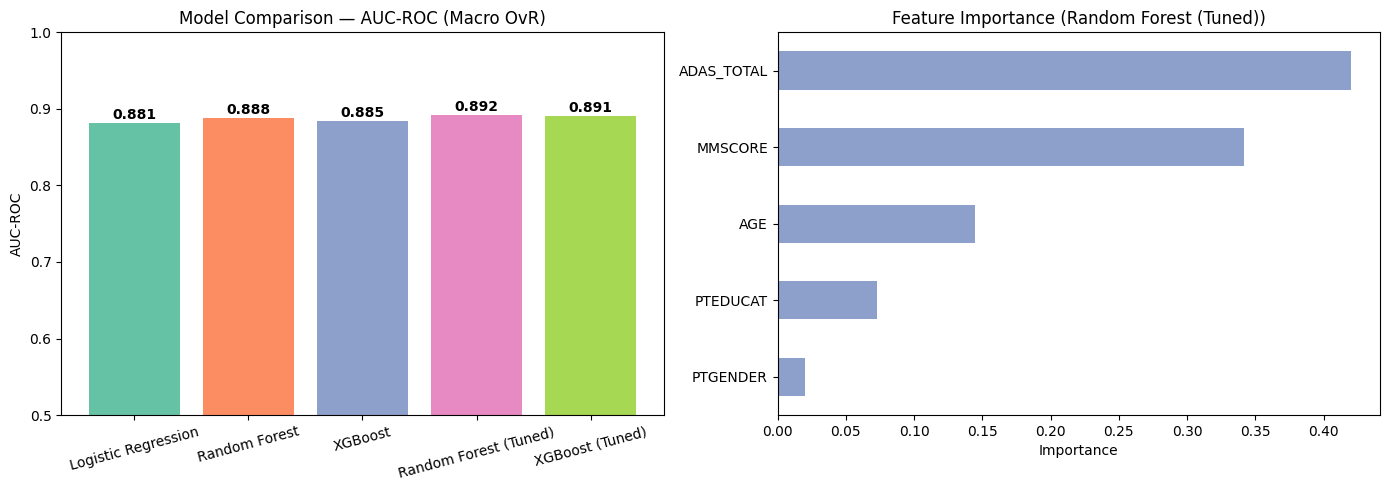


Best Model: Random Forest (Tuned)  (AUC: 0.8925)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC-ROC Comparison
model_names = list(results.keys())
aucs = [results[m]['auc'] for m in model_names]
bars = axes[0].bar(model_names, aucs,
                   color=['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854'])
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('Model Comparison — AUC-ROC (Macro OvR)')
axes[0].set_ylabel('AUC-ROC')
axes[0].tick_params(axis='x', rotation=15)
for bar, auc in zip(bars, aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{auc:.3f}', ha='center', fontweight='bold')

# Feature Importance
best_name = max(results, key=lambda x: results[x]['auc'])
best_model = results[best_name]['model']
if hasattr(best_model, 'best_estimator_'):
    fi = best_model.best_estimator_.feature_importances_
else:
    fi = best_model.feature_importances_

feat_imp = pd.Series(fi, index=X.columns).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[1], color='#8da0cb')
axes[1].set_title(f'Feature Importance ({best_name})')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print(f"\nBest Model: {best_name}  (AUC: {results[best_name]['auc']:.4f})")

**Final Model Performance Comparison**:

| Model | AUC-ROC |
|---|---|
| Logistic Regression | 0.881 |
| Random Forest | 0.888 |
| XGBoost | 0.885 |
| Random Forest (Tuned) | **0.893** ← Best |
| XGBoost (Tuned) | 0.891 |

**Random Forest (Tuned)** was selected as the model with the best final performance (AUC-ROC 0.893).

**Interpretation of Feature Importance**:
MMSCORE and ADAS_TOTAL showed the highest importance, confirming that cognitive function scores are the most critical variables for classifying CN, MCI, and AD.
AGE showed moderate importance, while PTEDUCAT and PTGENDER showed relatively low importance.
This underscores the importance of standardized cognitive assessment tools in early Alzheimer's screening.

## 3-5. ROC Curves (Best Model)

Plot per-class ROC curves for the best-performing model to assess discriminative performance for each diagnostic category.

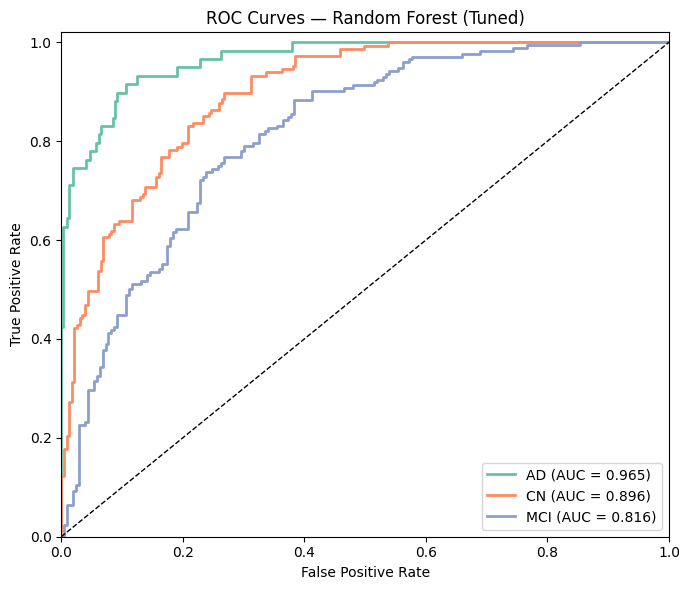

In [ ]:
from sklearn.metrics import roc_curve, auc as sk_auc

best_prob = results[best_name]['y_prob']
class_names = le.classes_
colors = ['#66c2a5', '#fc8d62', '#8da0cb']

fig, ax = plt.subplots(figsize=(7, 6))
for i, (cls, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_prob[:, i])
    roc_auc = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curves — {best_name}')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

The ROC curves evaluate each class using a "One-vs-Rest" approach.

- AD Curve: The closer the curve is to the top-left corner, the better the detection performance.
A high AD AUC indicates effective differentiation of Alzheimer's patients from the Normal (CN) and MCI groups.
- CN Curve: Represents detection performance for the normal group; it typically shows the highest AUC.
- MCI Curve: Expected to show the lowest AUC among the three classes;
this is due to the heterogeneous nature of MCI (existing on a continuous spectrum between CN and AD).
The diagonal line (dotted) represents a random classifier; since all curves lie significantly above this diagonal,
it confirms that all three models perform far better than random prediction.

---
# PART 4: Cross-Dataset Discussion

This section bridges the ADNI and SHHS findings. Since the two datasets do not share participants, a direct merge is not possible. Instead, we synthesize insights from both analyses:

- **From ADNI**: which cognitive features best distinguish CN / MCI / AD groups
- **From SHHS**: how sleep architecture (especially Stage 3 and REM) changes with age

Together, these findings support the hypothesis that wearable-derived sleep metrics could serve as low-cost, non-invasive proxies for early Alzheimer's risk screening.

> The cross-dataset narrative will be expanded in the written paper (Introduction, Literature Review, Discussion sections).

## 4-1. Key Findings Summary

Print a consolidated summary of findings from both datasets.

In [ ]:
print("=" * 55)
print("ADNI KEY FINDINGS")
print("=" * 55)
print(f"  Participants (after preprocessing): {len(df_adni)}")
print(f"  CN: {(df_adni['DIAGNOSIS']=='CN').sum()}  |  "
      f"MCI: {(df_adni['DIAGNOSIS']=='MCI').sum()}  |  "
      f"AD: {(df_adni['DIAGNOSIS']=='AD').sum()}")
print(f"  MMSE mean — CN: {df_adni[df_adni.DIAGNOSIS=='CN']['MMSCORE'].mean():.1f}  "
      f"MCI: {df_adni[df_adni.DIAGNOSIS=='MCI']['MMSCORE'].mean():.1f}  "
      f"AD: {df_adni[df_adni.DIAGNOSIS=='AD']['MMSCORE'].mean():.1f}")
print(f"  Best model AUC-ROC: {results[best_name]['auc']:.4f} ({best_name})")

print()
print("=" * 55)
print("SHHS KEY FINDINGS")
print("=" * 55)
print(f"  Participants (after preprocessing): {len(df_shhs)}")
print(f"  Mean REM %:         {df_shhs['nsrr_pctdursp_sr'].mean():.1f}")
print(f"  Mean Deep Sleep %:  {df_shhs['nsrr_pctdursp_s3'].mean():.1f}")
print(f"  Mean Sleep Efficiency: {df_shhs['nsrr_ttleffsp_f1'].mean():.1f}")
print(f"  Mean AHI:           {df_shhs['nsrr_ahi_hp3u'].mean():.1f}")

ADNI KEY FINDINGS
  Participants (after preprocessing): 1887
  CN: 736  |  MCI: 857  |  AD: 294
  MMSE mean — CN: 29.1  MCI: 27.5  AD: 23.1
  Best model AUC-ROC: 0.8925 (Random Forest (Tuned))

SHHS KEY FINDINGS
  Participants (after preprocessing): 5576
  Mean REM %:         19.8
  Mean Deep Sleep %:  18.2
  Mean Sleep Efficiency: 82.9
  Mean AHI:           14.6


**Summary of Key ADNI Results**:
- Analysis of 1,887 subjects (CN: 736 / MCI: 857 / AD: 294)
- Mean MMSE scores: CN (29.1) → MCI (27.5) → AD (23.1), showing a clear downward trend across groups
- Best-performing model: Random Forest (Tuned), AUC-ROC **0.893**

**Summary of Key SHHS Results**:
- Analysis of 5,576 subjects (adults aged 40–89)
- Mean REM sleep: 19.8%; mean deep sleep: 18.2% (slightly below normal reference ranges);
both metrics showed a declining trend with increasing age
- Mean sleep efficiency: 82.9% (below the clinical normal threshold of 85%)
- Mean AHI: 14.6 (borderline for mild sleep apnea)

**Link Between the Two Datasets**:
Common patterns were observed across both datasets: cognitive decline associated with aging in ADNI,
and a reduction in deep sleep and REM sleep associated with aging in SHHS.
These findings indirectly support the study's core hypothesis that changes in sleep architecture
(specifically, reductions in slow-wave sleep and REM sleep) may serve as potential biomarkers for cognitive decline.
If an integrated cohort with overlapping participants from both datasets is established in the future,
it will be possible to develop more robust screening models that directly incorporate sleep variables as features.